<a href="https://colab.research.google.com/github/elijahmoon-hub/Elijah-s-repository/blob/main/ElijMoon_Unit7Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Introduction

For my Unit 7 project, I will be creating multiple models with multiple predictors to predict the total weight of an octopus's beak. The factors I will be considering are the total weight, weight of upper beak, weight of lower beak, and the length of the wall on the beak.

In [ ]:
!pip install git+https://github.com/pydata/xarray.git
!pip install bambi

In [ ]:
import numpy as np
import pandas as pd
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt
import xarray as xr
import bambi as bmb
import graphviz as gv

In [ ]:
oc_data = pd.read_csv("https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/e0eea635673e8c28f825d0940d8e83499654a1e6/Data/octopusbeakweight_nlin.csv")
oc_data.head(5)

,totWt,upBeak,loBeak,latWall
0,91,78,78,74
1,532,125,120,131
2,537,101,92,138
3,605,85,107,135
4,647,130,101,155


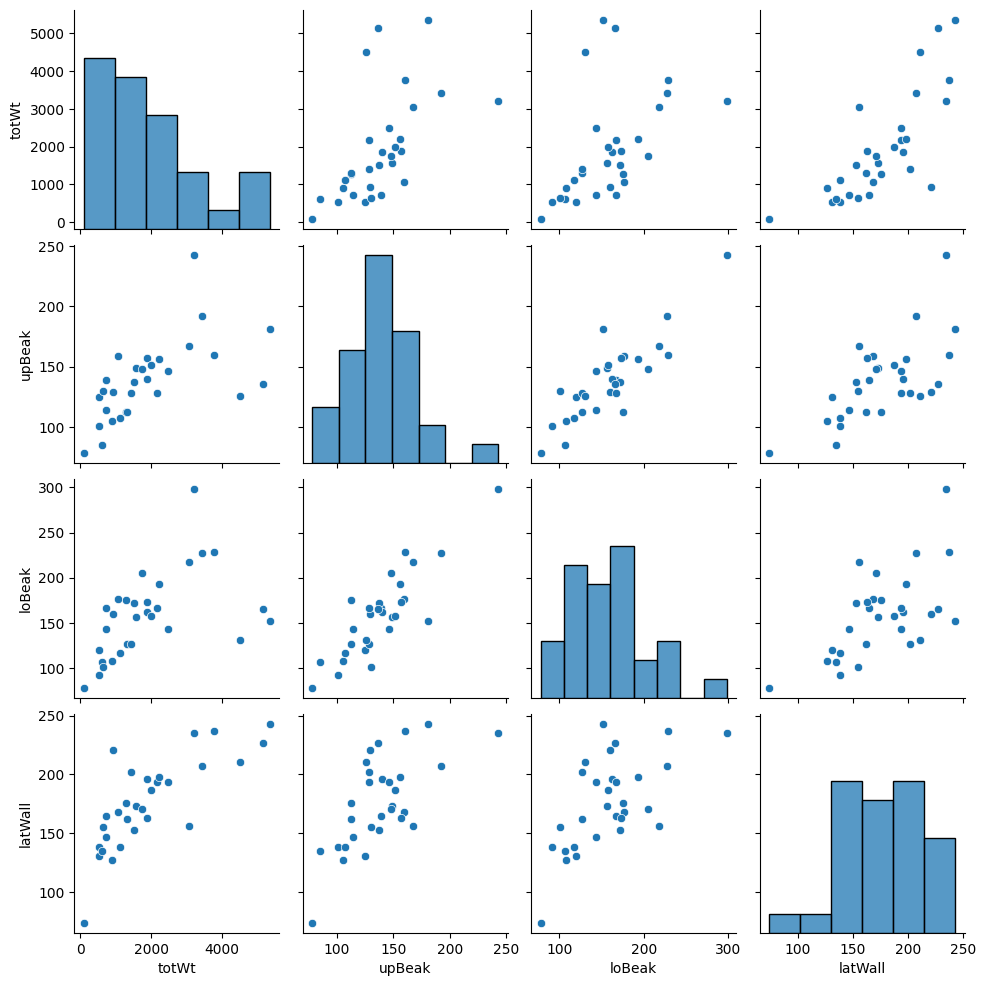

In [ ]:
oc_data = pd.read_csv("https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/e0eea635673e8c28f825d0940d8e83499654a1e6/Data/octopusbeakweight_nlin.csv")
sns.pairplot(oc_data)

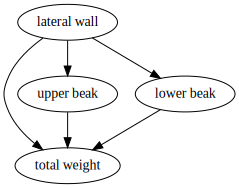

In [ ]:
b_dag = gv.Digraph(name="")
b_dag.node('tw','total weight')
b_dag.node('ub','upper beak')
b_dag.node('lb','lower beak')
b_dag.node('lw','lateral wall')
b_dag.edges([('lw','tw'),('ub','tw'),('lb','tw'),('lw','lb'),('lw','ub')])
b_dag

##Models

##Linear Model (Upper Beak)

In [ ]:
model1 = bmb.Model("totWt ~ upBeak", oc_data, family="t")
idata1 = model1.fit(idata_kwargs={'log_likelihood': True})

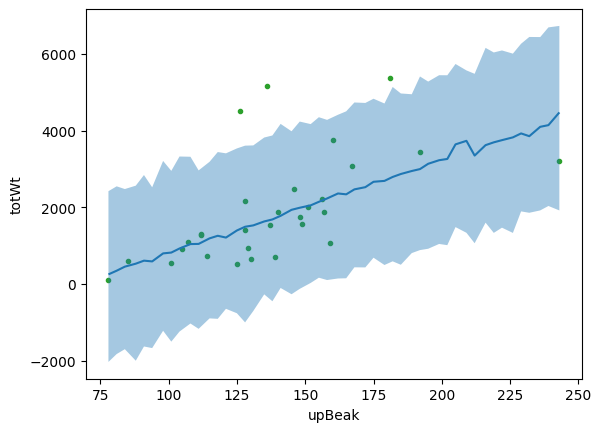

In [ ]:
bmb.interpret.plot_predictions(model1, idata1, "upBeak", pps=True)
plt.plot(oc_data.upBeak, oc_data.totWt, "C2.", zorder=-3)

This model used the weight of the upper break to predict the total beak weight. This model looks good and matches the overall upward trend that the total weight of the beak increases as the upper beak increases.

However, this first degree linear model lacks depth and a lot of the specifics in the data isn't modeled well.

##Polynomial Model (Upper beak)

In [ ]:
model2 = bmb.Model("totWt ~ poly(upBeak, degree = 3)", oc_data)
idata2 = model2.fit(idata_kwargs={'log_likelihood': True})

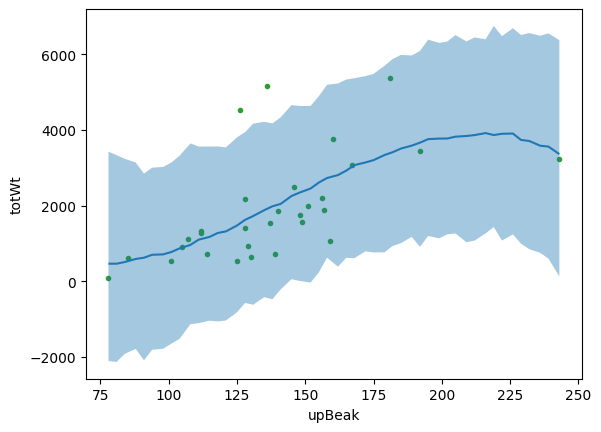

In [ ]:
bmb.interpret.plot_predictions(model2, idata2, "upBeak", pps=True)
plt.plot(oc_data.upBeak, oc_data.totWt, "C2.", zorder=-3)

This follows the general uptrend very well but due to having a degree of 4, does a much better job of matching the data from the scatterplot. The model matches the curves as it hits the peak before going back down. It matches the scatterplot well.

##Polynomial Model (LatWall)

In [ ]:
model3 = bmb.Model("totWt ~ poly(latWall, degree = 4) + upBeak:latWall + loBeak:latWall", oc_data)
idata3 = model3.fit(idata_kwargs={'log_likelihood': True})

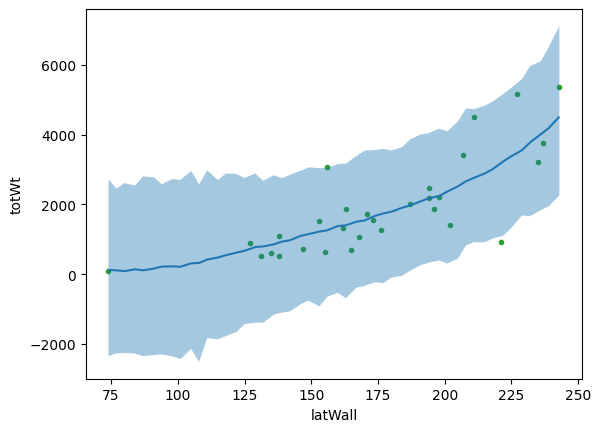

In [ ]:
bmb.interpret.plot_predictions(model3, idata3, "latWall", pps=True)
plt.plot(oc_data.latWall, oc_data.totWt, "C2.", zorder=-3)

##B-Spline model (latWall)

In [ ]:
num_knots = 3 # Adjusted number of knots
knots = np.linspace(131, 243, num_knots + 2)[1:-1]
model4 = bmb.Model("totWt ~ bs(latWall, degree = 3, knots = knots) + upBeak:latWall +loBeak:latWall", oc_data)
idata4 = model4.fit(idata_kwargs={'log_likelihood': True}, target_accept=0.9)

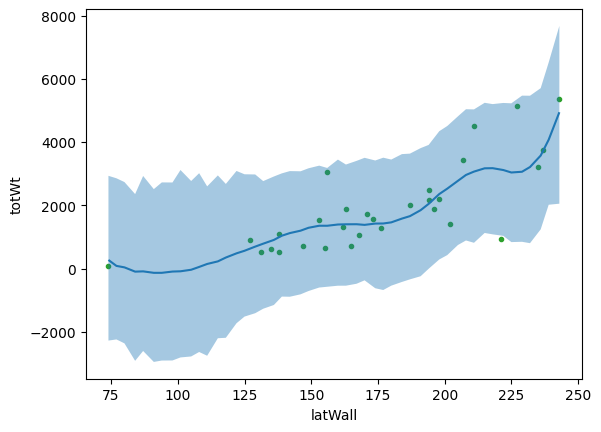

In [ ]:
bmb.interpret.plot_predictions(model4, idata4, "latWall", pps=True )
plt.plot(oc_data.latWall, oc_data.totWt, "C2.", zorder=-3)

I created the B-spline model to better match the cruves of the plot better alongwith the interactions of latWall. The B-spline model did a much better job creating a polynomial model for the lateral wall. This model was able to match the curves and ups and downs, which matches the datapoints very well.

##Multiple Linear Three-Factor Model

In [ ]:
model5 = bmb.Model("totWt ~ upBeak:totWt + latWall + loBeak:totWt : upBeak", data=oc_data)
idata5 = model5.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='upBeak', ylabel='totWt'>], dtype=object))

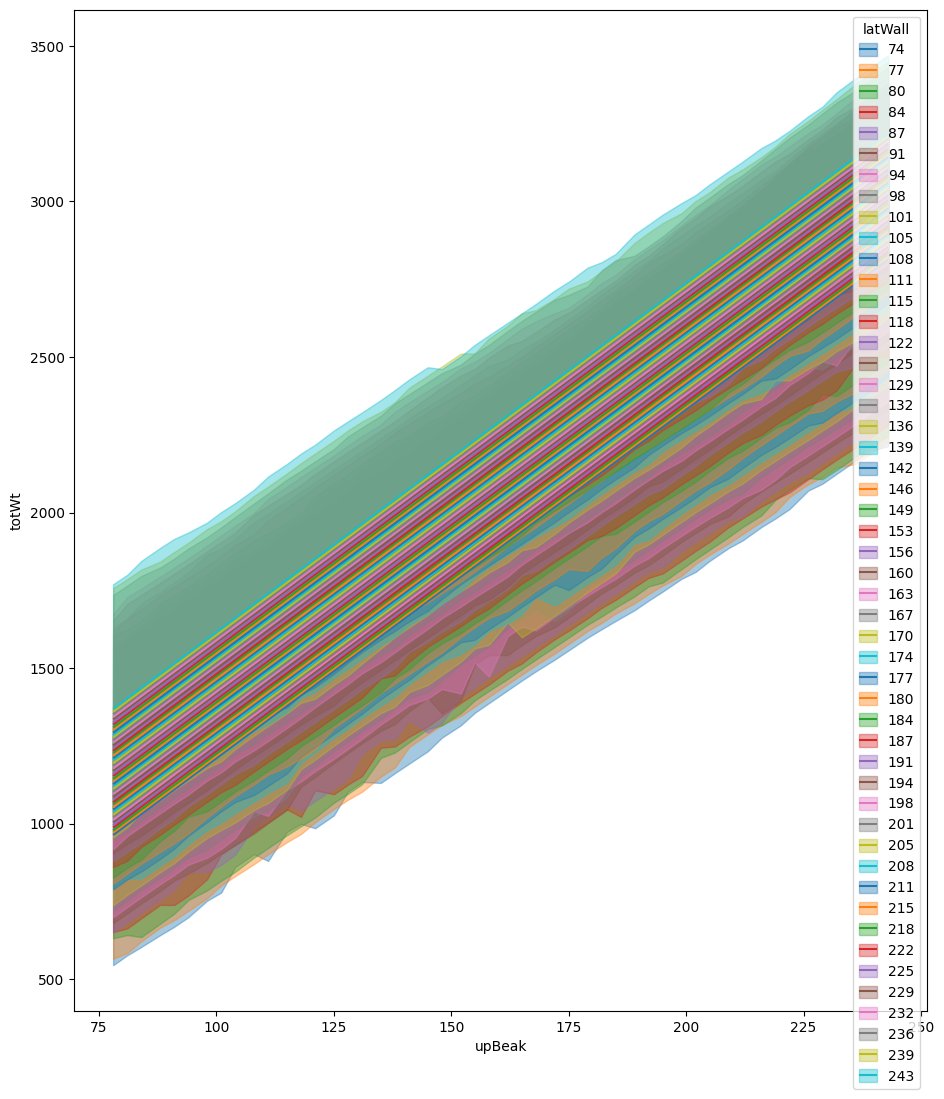

In [ ]:
bmb.interpret.plot_predictions(model5,
                               idata5,
                               ["upBeak", "latWall"],
                               fig_kwargs={"figsize":(11, 13)})

I created this multi-linear model containing all the variables and the interactions. From first looks, this visualization looks great.

In [ ]:
model6 = bmb.Model("totWt ~ poly(upBeak, degree = 2) + latWall + poly(loBeak, degree = 2) : upBeak", data=oc_data)
idata6 = model6.fit(idata_kwargs={'log_likelihood': True}, target_accept=0.9)

(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='upBeak', ylabel='totWt'>], dtype=object))

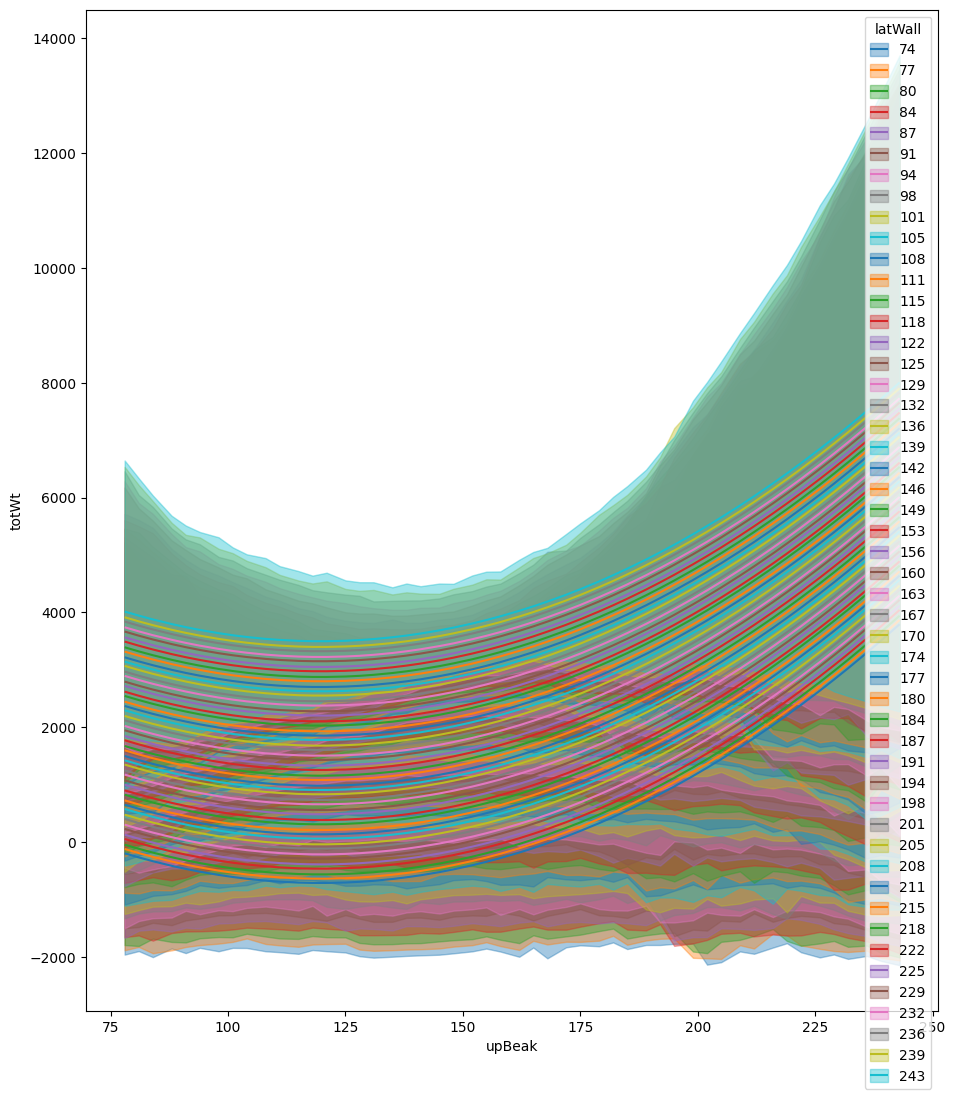

In [ ]:
bmb.interpret.plot_predictions(model6,
                               idata6,
                               ["upBeak", "latWall"],
                               fig_kwargs={"figsize":(11, 13)})

In [ ]:
cmp = az.compare({"UpBeak (linear)": idata1,"UpBeak (poly)": idata2, "Latwall (poly)": idata3, "Latwall (B-spline)": idata4, "All variable": idata5, "All variables (poly)": idata6})

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

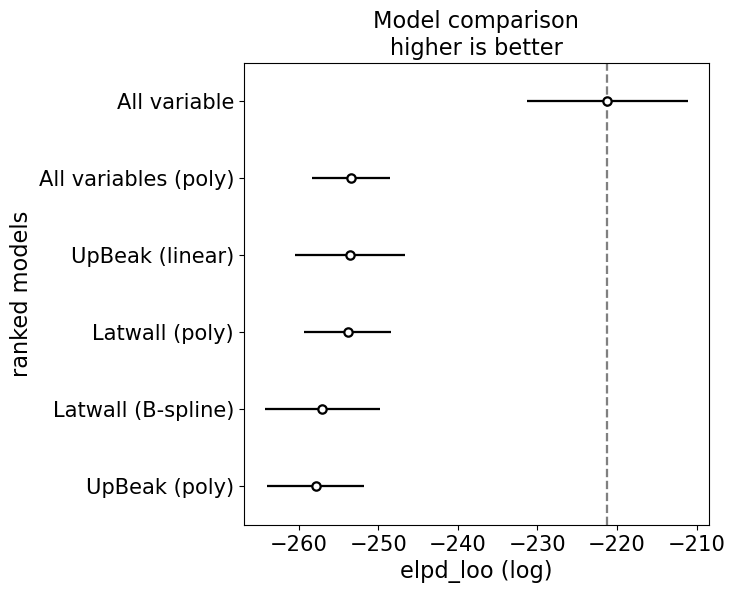

In [ ]:
az.plot_compare(cmp)

After analyzing my elpd_loo, i found that my initial models, models 1 and 2 were not the best, which is where I created a linear and polynomial model for the upper beak. The linear model performed the second best which I expected but Im surprised that the polynomial model ran significantly worse.The size of the upper beak seemed to be a good predictor in the total weight of the beak, but my models showed otherwise. I found that my multi-linear model with all the factors was my most accurate model also makes logical sense as the length of all componenets of an octupus's beak should correlate almost completely with the size and therefore weight of the beak.